In [ ]:
#Global YouTube Statistics Analysis using NumPy, Statistics, and EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("C:/Users/sahil/OneDrive/Desktop/ITvedant/EDA/Global YouTube Statistics.csv", encoding='latin1')
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (995, 28)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    str    
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    str    
 5   Title                                    995 non-null    str    
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    str    
 8   Abbreviation                             873 non-null    str    
 9   channel_type                             965 non-null    str    
 10  video_views_rank                         994 non-null    floa

In [5]:
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.940000e+02,879.000000,962.000000,9.390000e+02,995.000000,9.950000e+02,9.950000e+02,9.950000e+02,6.580000e+02,990.000000,990.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.542489e+05,386.053470,745.719335,1.756103e+08,36886.148281,5.898078e+05,4.422574e+05,7.081814e+06,3.490791e+05,2012.630303,15.746465,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362782e+06,1232.244746,1944.386561,4.163782e+08,71858.724092,1.148622e+06,8.612161e+05,1.379704e+07,6.143554e+05,4.512503,8.777520,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.230000e+02,11.000000,27.000000,2.013750e+07,2700.000000,4.350000e+04,3.265000e+04,5.217500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.000000,65.500000,6.408500e+07,13300.000000,2.127000e+05,1.595000e+05,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.584500e+03,123.000000,139.750000,1.688265e+08,37900.000000,6.068000e+05,4.551000e+05,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,1.020000e+07,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


In [6]:
missing_values = df.isnull().sum()

In [7]:
missing_values[missing_values > 0]

category                                    46
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
subscribers_for_last_30_days               337
created_year                                 5
created_month                                5
created_date                                 5
Gross tertiary education enrollment (%)    123
Population                                 123
Unemployment rate                          123
Urban_population                           123
Latitude                                   123
Longitude                                  123
dtype: int64

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [9]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print("Missing Values Handled")

Missing Values Handled


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df.drop_duplicates(inplace=True)
print("Duplicates Removed")

Duplicates Removed


In [12]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='str')

In [14]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['rank', 'youtuber', 'subscribers', 'video_views', 'category', 'title',
       'uploads', 'country', 'abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'gross_tertiary_education_enrollment_(%)', 'population',
       'unemployment_rate', 'urban_population', 'latitude', 'longitude'],
      dtype='str')

In [15]:
df.head()

,rank,youtuber,subscribers,video_views,category,title,uploads,country,abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [16]:
top_subscribers = df.sort_values(by='subscribers', ascending=False).head(10)
top_subscribers[['youtuber', 'subscribers']]

,youtuber,subscribers
0,T-Series,245000000
1,YouTube Movies,170000000
2,MrBeast,166000000
3,Cocomelon - Nursery Rhymes,162000000
4,SET India,159000000
5,Music,119000000
6,ýýý Kids Diana Show,112000000
7,PewDiePie,111000000
8,Like Nastya,106000000
9,Vlad and Niki,98900000


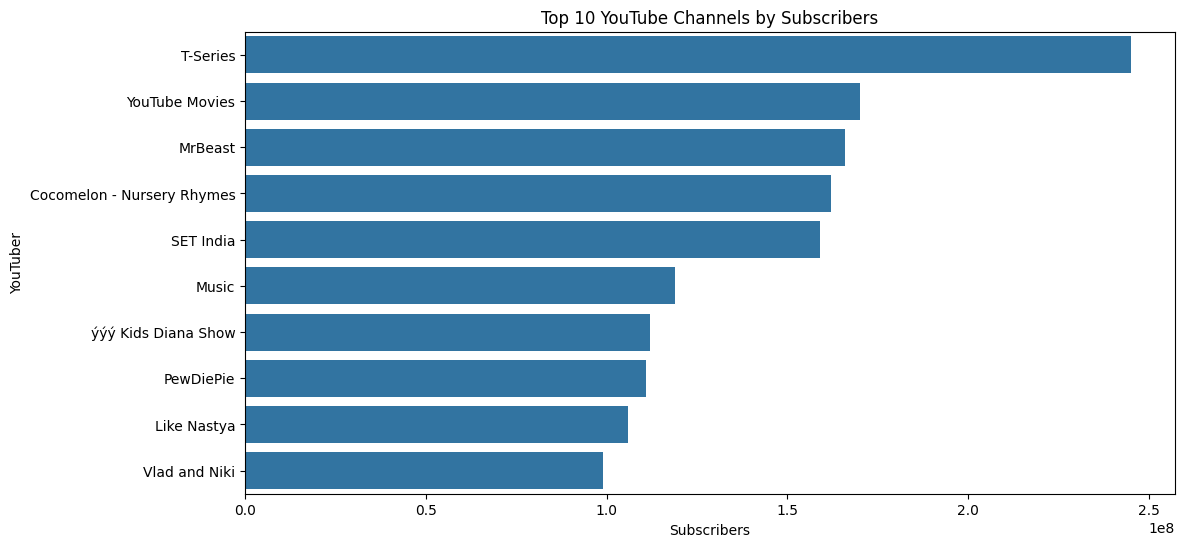

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='subscribers',
    y='youtuber',
    data=top_subscribers
)
plt.title("Top 10 YouTube Channels by Subscribers")
plt.xlabel("Subscribers")
plt.ylabel("YouTuber")
plt.show()

In [18]:
top_countries = df['country'].value_counts().head(10)
top_countries

country
United States     313
India             168
Brazil             62
United Kingdom     43
Mexico             33
Indonesia          28
Spain              22
Thailand           18
South Korea        17
Russia             16
Name: count, dtype: int64

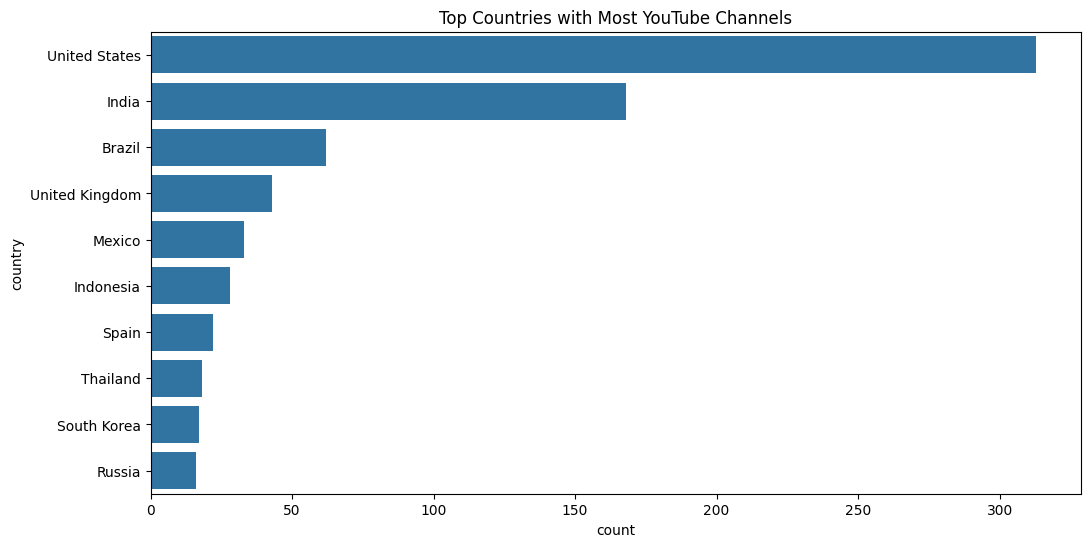

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='country',
    data=df,
    order=df['country'].value_counts().head(10).index
)
plt.title("Top Countries with Most YouTube Channels")
plt.show()

In [20]:
mean_subscribers = np.mean(df['subscribers'])
print("Average Subscribers:", mean_subscribers)

Average Subscribers: 22982412.06030151


In [21]:
median_views = np.median(df['video_views'])
print("Median Video Views:", median_views)

Median Video Views: 7760819588.0


In [22]:
std_views = np.std(df['video_views'])
print("Standard Deviation of Views:", std_views)

Standard Deviation of Views: 14103751717.735266


In [23]:
variance_views = np.var(df['video_views'])
print("Variance:", variance_views)

Variance: 1.9891581251552045e+20


In [24]:
correlation = df[['subscribers', 'video_views', 'uploads']].corr()
correlation

,subscribers,video_views,uploads
subscribers,1.000000,0.750958,0.077136
video_views,0.750958,1.000000,0.165928
uploads,0.077136,0.165928,1.000000


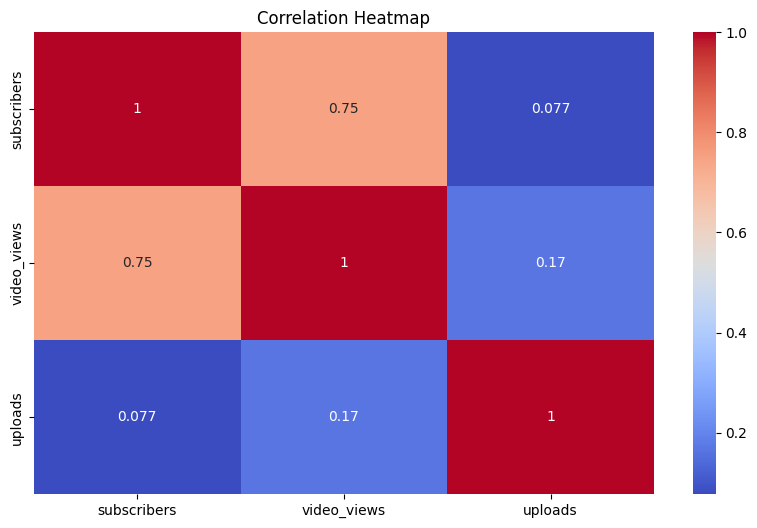

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

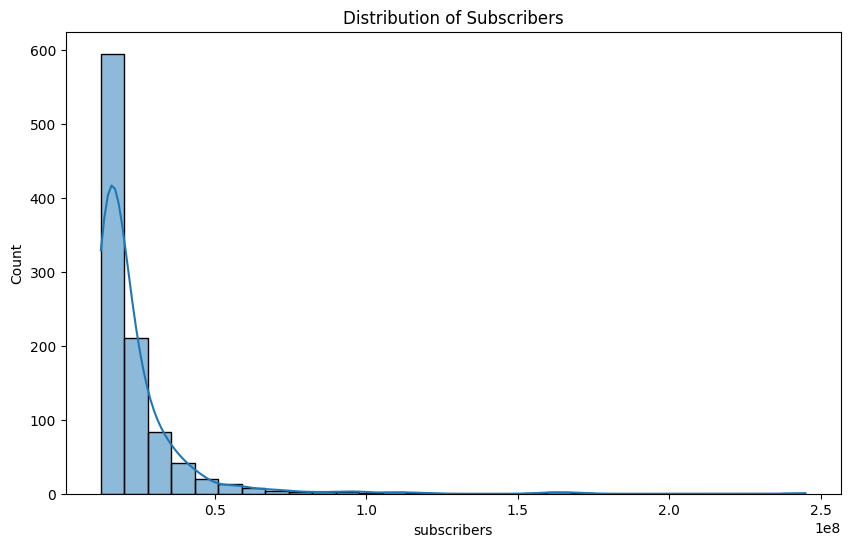

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df['subscribers'], bins=30, kde=True)
plt.title("Distribution of Subscribers")
plt.show()

In [37]:
Q1 = df['video_views'].quantile(0.25)
Q3 = df['video_views'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_no_outliers = df[
    (df['video_views'] >= lower_limit) &
    (df['video_views'] <= upper_limit)
]
print("Original Shape:", df.shape)
print("New Shape:", df_no_outliers.shape)

Original Shape: (995, 29)
New Shape: (943, 29)


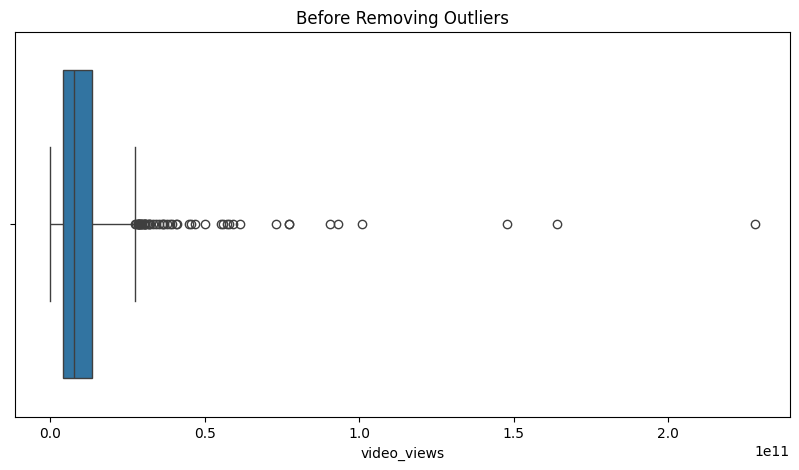

In [38]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['video_views'])
plt.title("Before Removing Outliers")
plt.show()

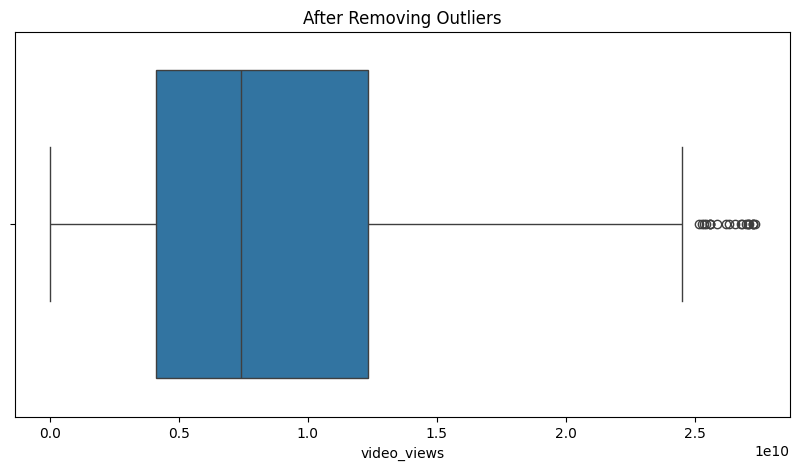

In [39]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_no_outliers['video_views'])
plt.title("After Removing Outliers")
plt.show()

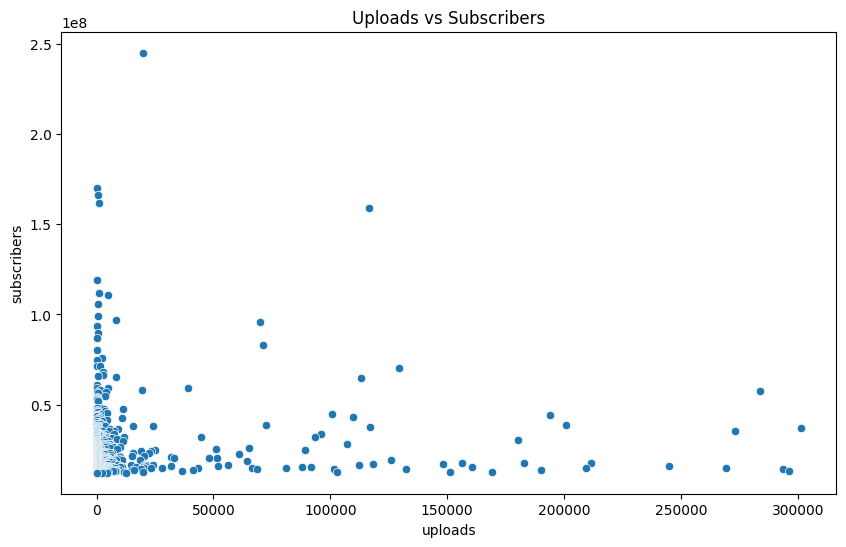

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='uploads',
    y='subscribers',
    data=df
)
plt.title("Uploads vs Subscribers")
plt.show()

In [30]:
category_analysis = df.groupby('category')['subscribers'].mean().sort_values(ascending=False)
category_analysis

category
Shows                    4.161538e+07
Trailers                 3.900000e+07
Film & Animation         2.858478e+07
Nonprofits & Activism    2.775000e+07
Sports                   2.710909e+07
Education                2.654222e+07
Music                    2.571782e+07
Movies                   2.565000e+07
Entertainment            2.140332e+07
People & Blogs           2.105606e+07
Gaming                   2.085213e+07
News & Politics          2.063077e+07
Comedy                   2.012319e+07
Howto & Style            1.939000e+07
Science & Technology     1.861765e+07
Pets & Animals           1.810000e+07
Autos & Vehicles         1.785000e+07
Travel & Events          1.250000e+07
Name: subscribers, dtype: float64

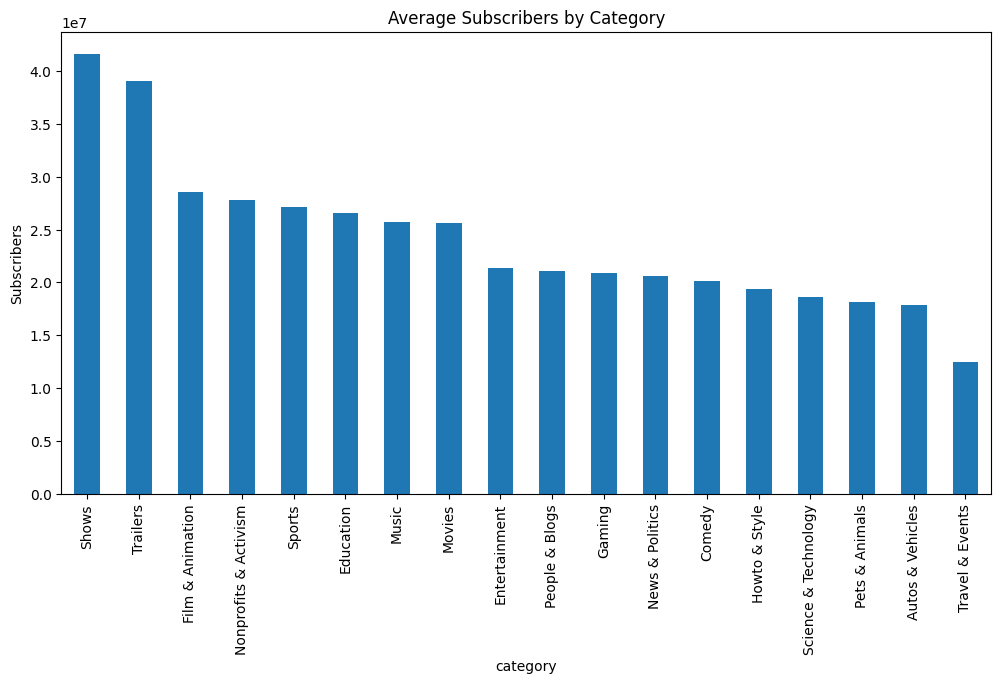

In [31]:
plt.figure(figsize=(12,6))
category_analysis.plot(kind='bar')
plt.title("Average Subscribers by Category")
plt.ylabel("Subscribers")
plt.show()

In [32]:
country_analysis = df.groupby('country')['subscribers'].mean().sort_values(ascending=False).head(10)
country_analysis

country
Cuba           4.630000e+07
El Salvador    4.610000e+07
Barbados       4.190000e+07
Japan          3.782000e+07
Venezuela      3.120000e+07
Kuwait         3.050000e+07
Chile          2.906667e+07
South Korea    2.833529e+07
Pakistan       2.590000e+07
India          2.565833e+07
Name: subscribers, dtype: float64

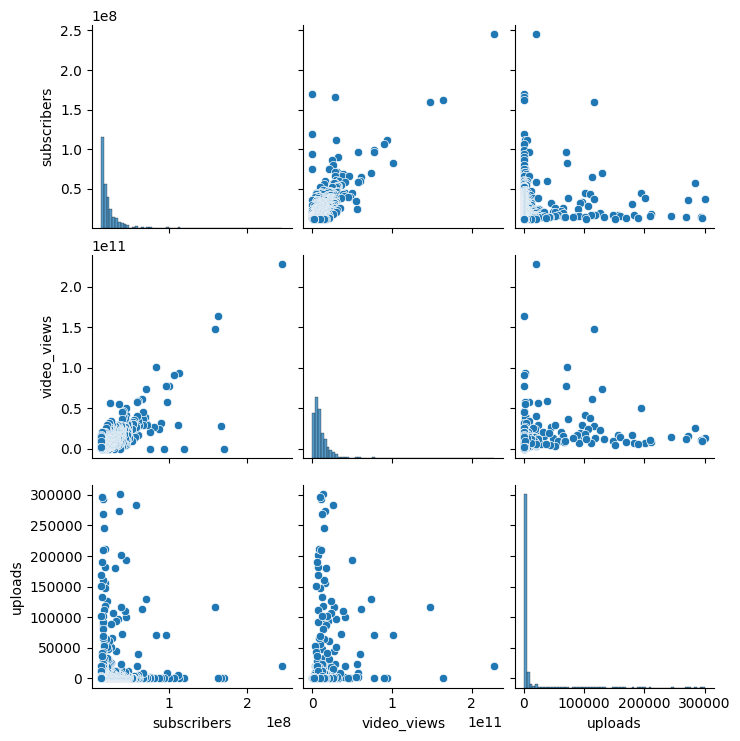

In [33]:
sns.pairplot(
    df[['subscribers', 'video_views', 'uploads']]
)
plt.show()

In [34]:
print("Skewness")
print(df[['subscribers', 'video_views']].skew())

print("\nKurtosis")
print(df[['subscribers', 'video_views']].kurt())

Skewness
subscribers    5.513643
video_views    7.209869
dtype: float64

Kurtosis
subscribers    45.745314
video_views    82.963122
dtype: float64


In [35]:
# Subscriber to Upload Ratio
df['subscriber_upload_ratio'] = df['subscribers'] / (df['uploads'] + 1)
df[['subscriber_upload_ratio']].head()

,subscriber_upload_ratio
0,1.219937e+04
1,8.500000e+07
2,2.237197e+05
3,1.675284e+05
4,1.364374e+03


In [36]:
efficient_channels = df.sort_values(
    by='subscriber_upload_ratio',
    ascending=False
).head(10)
efficient_channels[['youtuber', 'subscriber_upload_ratio']]

,youtuber,subscriber_upload_ratio
5,Music,119000000.0
12,Gaming,93600000.0
1,YouTube Movies,85000000.0
57,BRIGHT SIDE,44500000.0
14,Goldmines,43450000.0
73,Luisito Comunica,40600000.0
16,5-Minute Crafts,40050000.0
102,News,36300000.0
113,T-Series Apna Punjab,34600000.0
149,Luis Fonsi,31400000.0
